<a href="https://colab.research.google.com/github/Otrname/Introduction-to-Generative-Artificial-Intelligence-by-Li-Hongyi-2025-/blob/main/%E2%80%9CGen_AI_ML_Hw1_ipynb_%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GenAI_ML_HW1

目标

1. 熟悉 Google Colab

2. 理解词元、分词器、提示和聊天模板的概念

3. 观察模型在不同提示设置下的表现

4. 学习如何使用 Gradio 构建简单的用户界面

# 激活 GPU

> 添加引用符号

要启用 GPU，请按照以下步骤操作：

1. 点击标题中的“运行时”（或“執行階段”）。
2. 点击下拉菜单中的“更改运行时类型”（或“變更執行階段類型”）。
3. 选择“T4 GPU”并保存。（如果您有 Colab Pro，可以选择“A100 GPU”或“V100 GPU”）
![EnableGPU.png]([Media removed: image/png, ~142620 chars])

# 检查 GPU

In [ ]:
!nvidia-smi

Tue May 12 10:41:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 下载并安装依赖项

本节设置使用大型语言模型 (LLM) 所需的库。

In [ ]:
# 卸载可能存在冲突的核心库版本

# 这可以防止版本不匹配导致运行时错误。
! pip uninstall -y transformers tokenizers huggingface_hub torch

# 安装 LLM 工作所需的基本库的最新版本：
# - transformers：用于预训练模型和分词器的 HuggingFace 库
# - torch：PyTorch 深度学习框架（Transformers 的后端）
# - torchvision：计算机视觉工具（通常作为依赖项）
! pip install transformers torch torchvision

Found existing installation: transformers 5.8.0
Uninstalling transformers-5.8.0:
  Successfully uninstalled transformers-5.8.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: huggingface_hub 1.14.0
Uninstalling huggingface_hub-1.14.0:
  Successfully uninstalled huggingface_hub-1.14.0
Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
  Using cached transformers-5.8.0-py3-none-any.whl.metadata (33 kB)
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached huggingface_hub-1.14.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached cuda_bindings-13.2.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.

In [ ]:
# HuggingFace Hub 访问的身份验证设置

# 导入必要的库：
# - torch：PyTorch 张量计算库
# - login：HuggingFace 身份验证函数
import torch
from huggingface_hub import login
from google.colab import userdata

# 重要提示：需要 HuggingFace 身份验证令牌
# 此令牌允许访问需要用户同意才能访问的受限模型
# 获取令牌：访问 huggingface.co -> 设置 -> 访问令牌 -> 创建新令牌
# 从 Colab secrets 中获取令牌
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 第一部分：理解大型语言模型中的词元
## 教学目标：
1. **词元级实现**：学习大型语言模型如何在词元级（而非词级）处理文本
2. **实际应用**：使用实际的分词器和模型组件来理解词元机制
3. **评估**：运用所学知识回答 NTUcool 平台上的问题

## 关键概念：

- **词元化**：将人类可读的文本转换为模型可以处理的数值词元的过程
- **词汇表**：模型能够理解的所有词元的集合（通常包含 3 万到 10 万个以上的词元）
- **词元 ID**：映射到特定文本片段（子词、字符或符号）的数值表示

### 以下区块用于问题 1 到 3



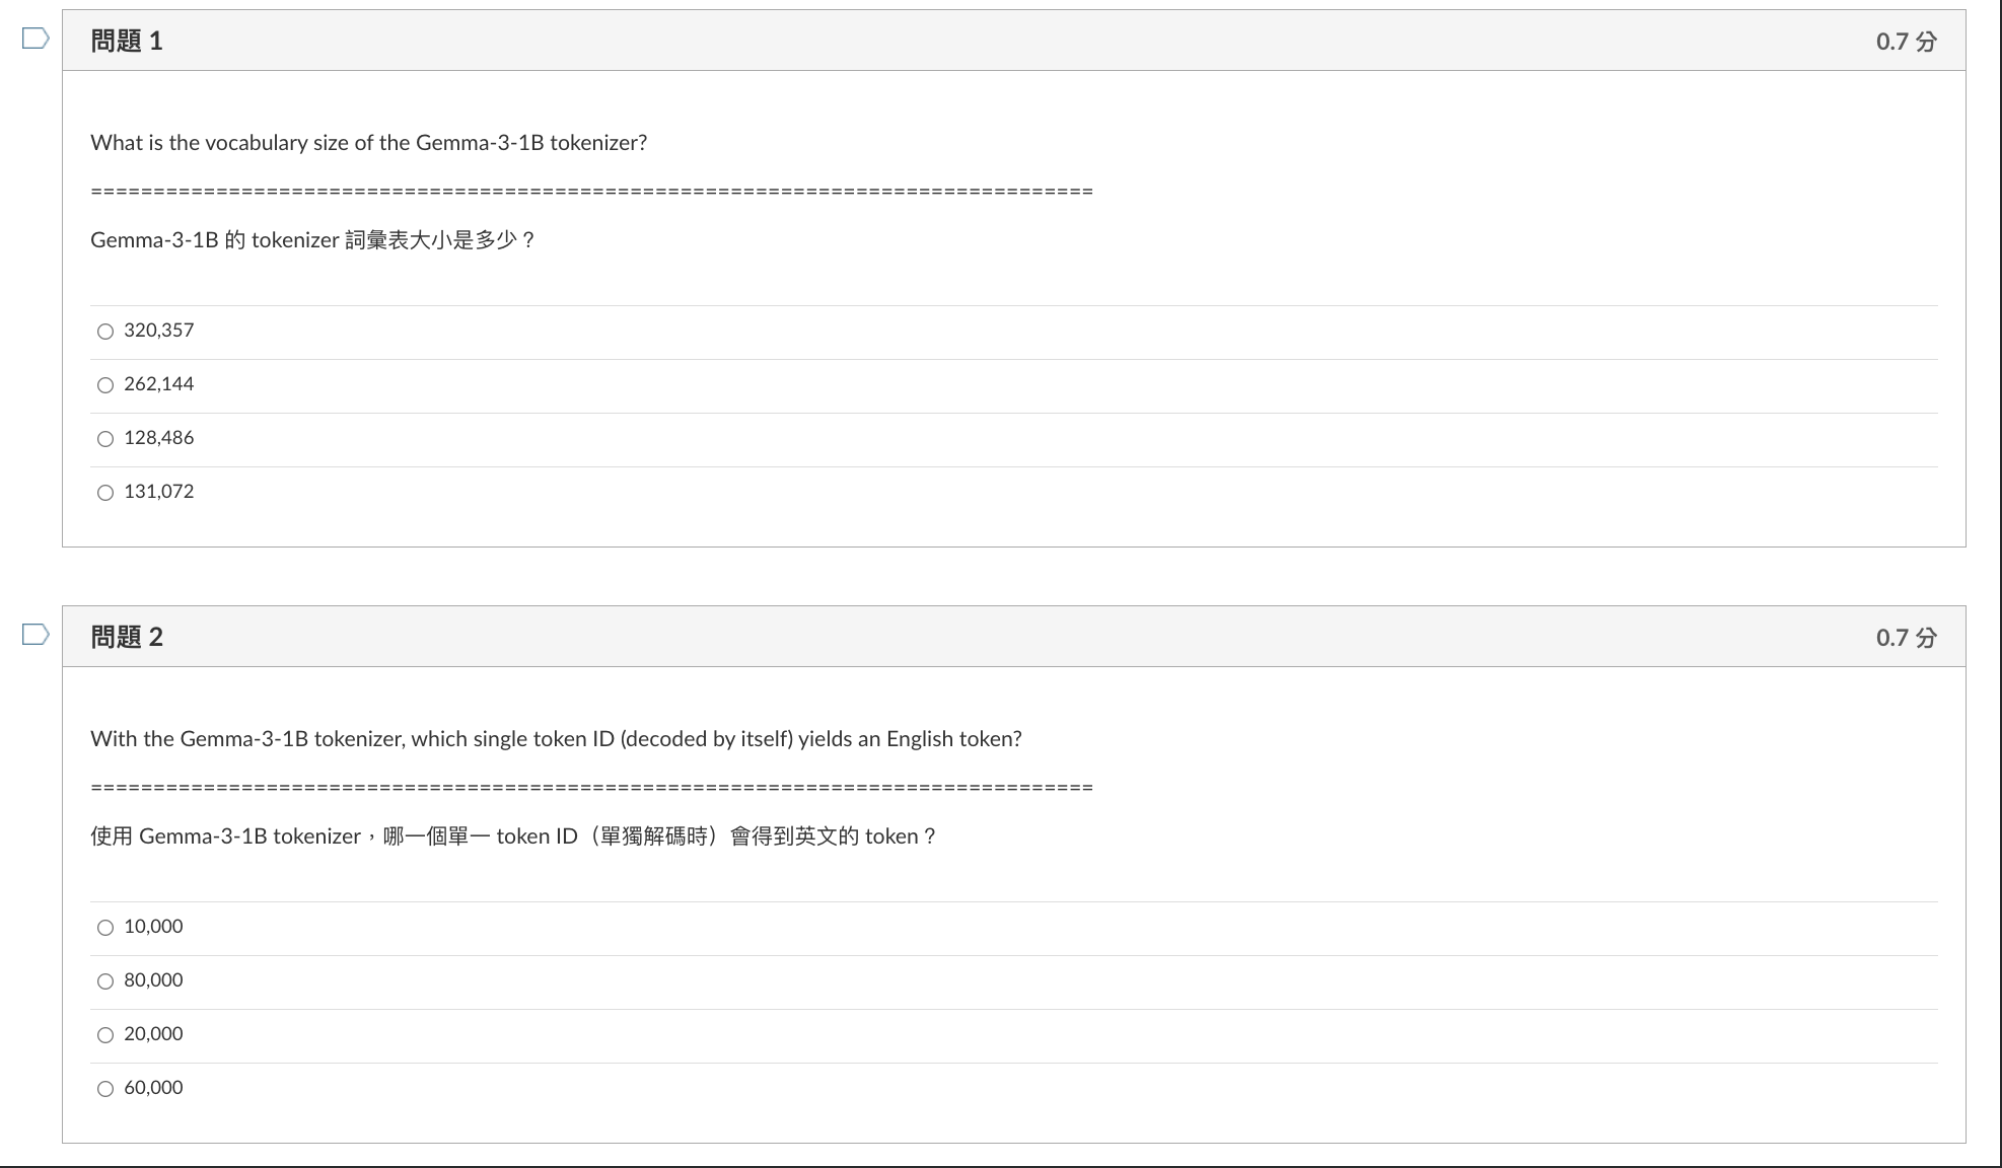

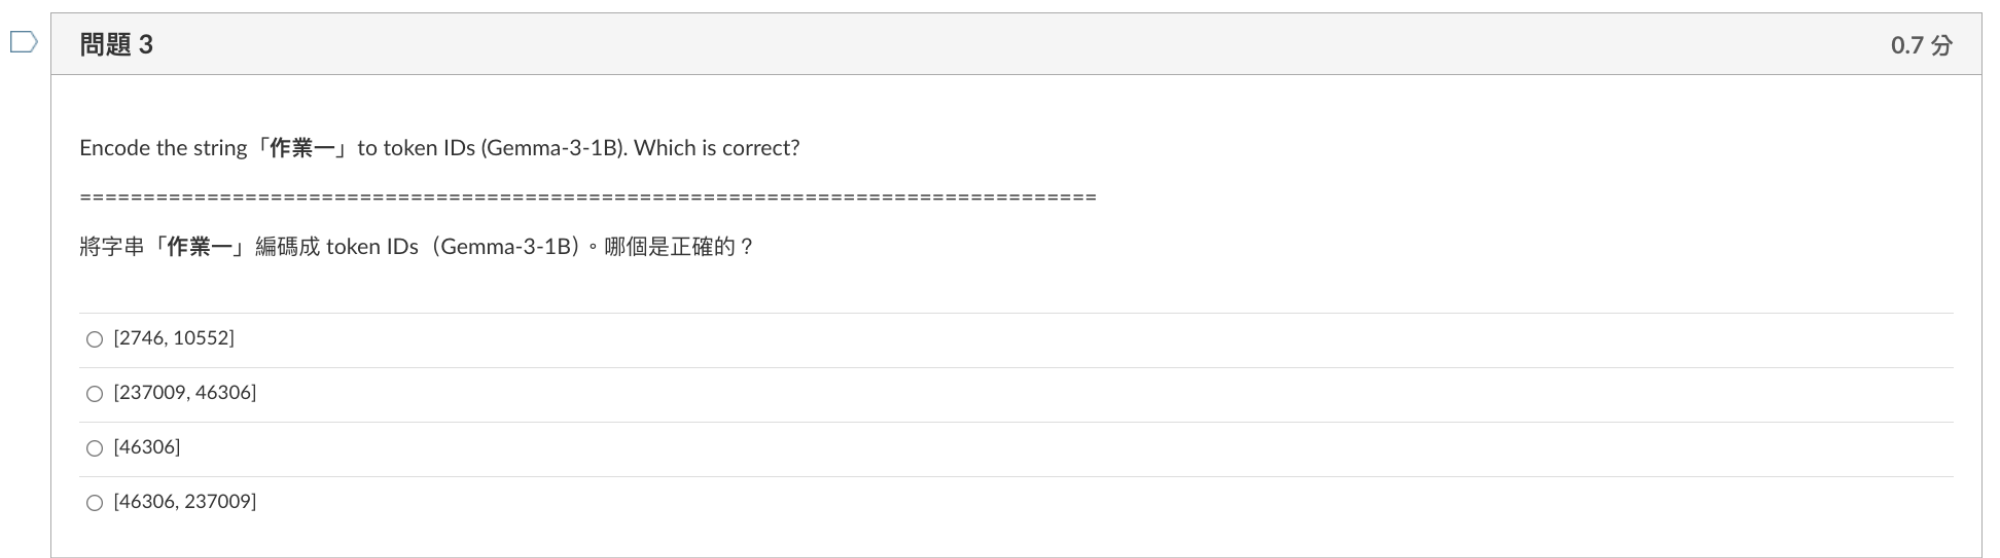

In [ ]:
# 用于词元分析的模型和分词器加载

# 导入 Transformer 核心组件：
# - AutoTokenizer：自动加载适用于任何模型的分词器
# - AutoModelForCausalLM：加载因果语言模型（根据先前的词元预测下一个词元）
from transformers import AutoTokenizer, AutoModelForCausalLM

# 注意：如果您想获得测验的正确答案，请勿更改 LLM_NAME
# 本次教学练习使用 google/gemma-3-1b-it
LLM_NAME = "google/gemma-3-1b-it"

# 分词器设置：在文本和数字标记之间进行转换
# 在 T4 GPU 环境下实现最佳性能的关键配置：
tokenizer = AutoTokenizer.from_pretrained(
    LLM_NAME,
    device_map="auto"              # 自动将模型分配到可用的计算设备上
                                   # 如果可用，将使用 GPU，否则回退到 CPU
)

# 模型设置：加载用于文本生成的实际神经网络
# 该网络包含数十亿个参数，这些参数经过训练，可以预测序列中的下一个词元
model = AutoModelForCausalLM.from_pretrained(LLM_NAME,device_map="auto")

device = "cuda" if torch.cuda.is_available() else "cpu"

# TODO: 请使用已加载的模型和分词器完成以下练习。


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

In [ ]:
#第一题答案
print("語言模型有多少不同的 Token 可以選擇：", tokenizer.vocab_size)

語言模型有多少不同的 Token 可以選擇： 262144


In [ ]:
#第二题答案
token_id = [100000, 80000, 20000, 60000] #这里可以放自由放入任何小于 tokenizer.vocab_size 的整数
print("Token 编号 ", token_id, " 是：", tokenizer.decode(token_id))           #结果选A：10000

Token 编号  [100000, 80000, 20000, 60000]  是：  Reactive Пла yoga आईपी


In [ ]:
#第三题答案
## 用 tokenizer.encode 把文字变成一串 token 编号

text = "作業一" #尝试自己输入任何文字 (例如: hi, 大家好)，看看encode后会得到什么
tokens = tokenizer.encode(text,add_special_tokens=False) #把 text 中的文字转成一串 token id，加上 add_special_tokens=False 可以避免加上代表起始的符号
print(text ,"->", tokens)                     # 答案选D

作業一 -> [46306, 237009]


以下区块用于问题 4
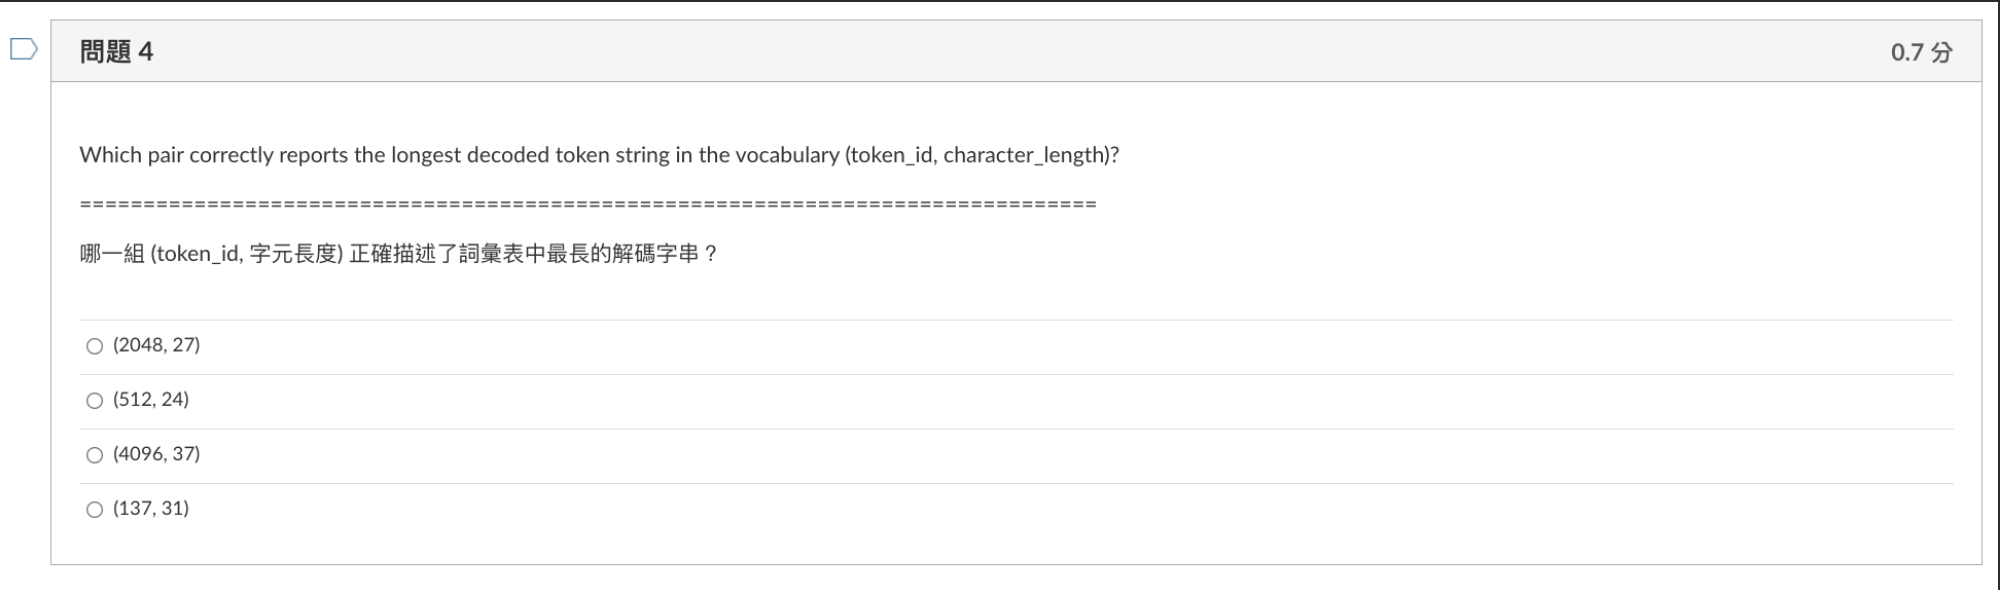

In [ ]:
# 创建一个全面的列表来分析词汇表中的所有词元
# 每个元素包含：(词元 ID, 解码文本, 字符长度)
tokens_with_length = []

# 遍历模型词汇表中所有可能的词元 ID
for token_id in range(tokenizer.vocab_size):
    # 将数字词元 ID 转换回人类可读的文本
    # 这揭示了每个词元代表的文本模式
    token = tokenizer.decode(token_id)

    # 存储词元信息及其长度以供分析
    tokens_with_length.append((token_id, token, len(token)))

# 按解码文本长度排序词元：最长 → 最短
tokens_with_length.sort(key=lambda x: x[2], reverse=True) # reverse=True: 最长优先, reverse=False: 最短优先

token_id, token_str, token_length = tokens_with_length[0]
print("词元 ID ", token_id, " 是：", "(长度:", token_length, ")")
print("token:", tokenizer.decode(token_id))              #答案是D


词元 ID  137  是： (长度: 31 )
token: 

































### 以下区块用于问题 5
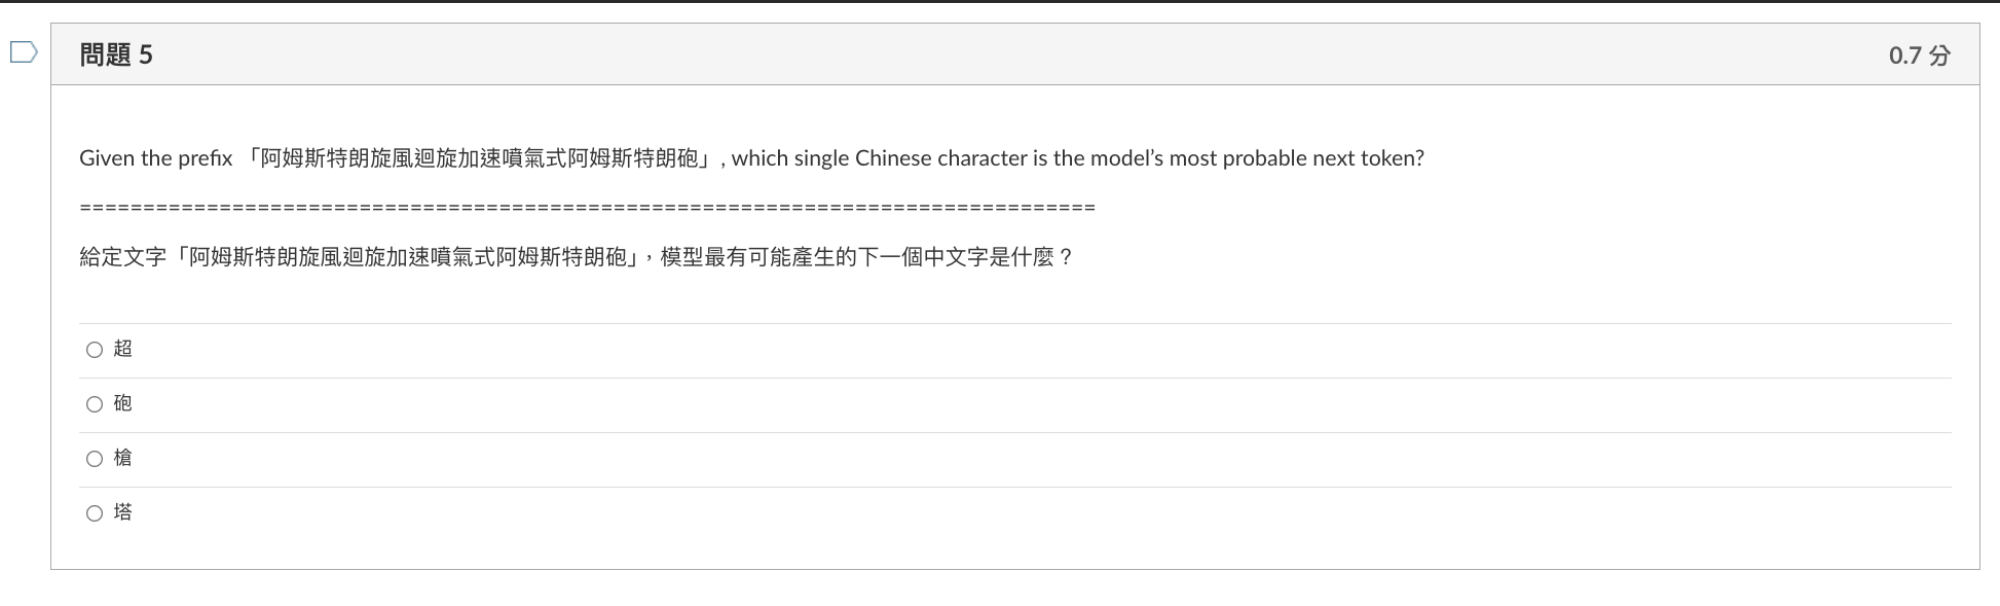

In [ ]:
# TODO: 将输入文本定义为“阿姆斯特朗旋風迴旋加速噴氣式阿姆斯特朗砲”
text = "阿姆斯特朗旋風迴旋加速噴氣式阿姆斯特朗砲"  # 替换为上述中文短语以进行正确分析
print(f"输入文字 (Input text): {text}")

# 步骤 1: 文本 → 词元
# 将人类可读的文本转换为模型可以处理的数字词元
input_ids = tokenizer.encode(text, return_tensors="pt").to(device)

# 步骤 2: 模型正向传播
# 将词元输入神经网络以获取预测分数 (logits)
# 每个位置预测所有可能下一个词元的概率分布
outputs = model(input_ids)

# 步骤 3: 提取下一个词元的预测

# TODO: 使用 outputs 提取最后一个位置的 logits
# 提示 outputs.logits 形状：[batch_size, sequence_length, vocab_size]
last_logits = outputs.logits[:, -1, :]


# 步骤 4: 将分数转换为概率
# Softmax 将原始 logits 转换为适当的概率分布（总和为 1.0）
probabilities = torch.softmax(last_logits, dim=-1)

# 步骤 5: 找到最可能的词元
# argmax 返回概率最高的词元 ID（贪婪选择）
max_prob_token_id = torch.argmax(probabilities, dim=-1).item()
max_probability = probabilities[0, max_prob_token_id].item()

# 步骤 6: 解码回人类可读的文本
## Convert the winning token IDs back to text to see what the model predicted
next_word = tokenizer.decode(max_prob_token_id)

# Results displayed
print(f"Next token ID that ranks first: {max_prob_token_id}")
print(f"Decoded text: '{next_word}'")
print(f"Probability: {max_probability:.4f} ({max_probability*100:.2f}%)")    #答案D

输入文字 (Input text): 阿姆斯特朗旋風迴旋加速噴氣式阿姆斯特朗砲
Next token ID that ranks first: 240019
Decoded text: '塔'
Probability: 0.1992 (19.92%)


# 第二部分：系统和用户提示工程

## 教学目标：
1. **提示工程**：学习如何通过系统和用户提示控制 AI 行为
2. **行为观察**：观察不同提示如何显著改变模型响应
3. **实际评估**：尝试修改提示以进行 NTUcool 评估

## 关键概念：
- **系统提示**：设置 AI 的角色、个性和行为约束（类似于角色描述）
- **用户提示**：人类用户实际的问题或请求
- **聊天模板**：经过指令微调的模型期望的正确格式，以实现最佳性能
- **提示工程**：精心设计提示以实现所需 AI 行为的艺术和科学

### 以下区块用于问题 6 到 8
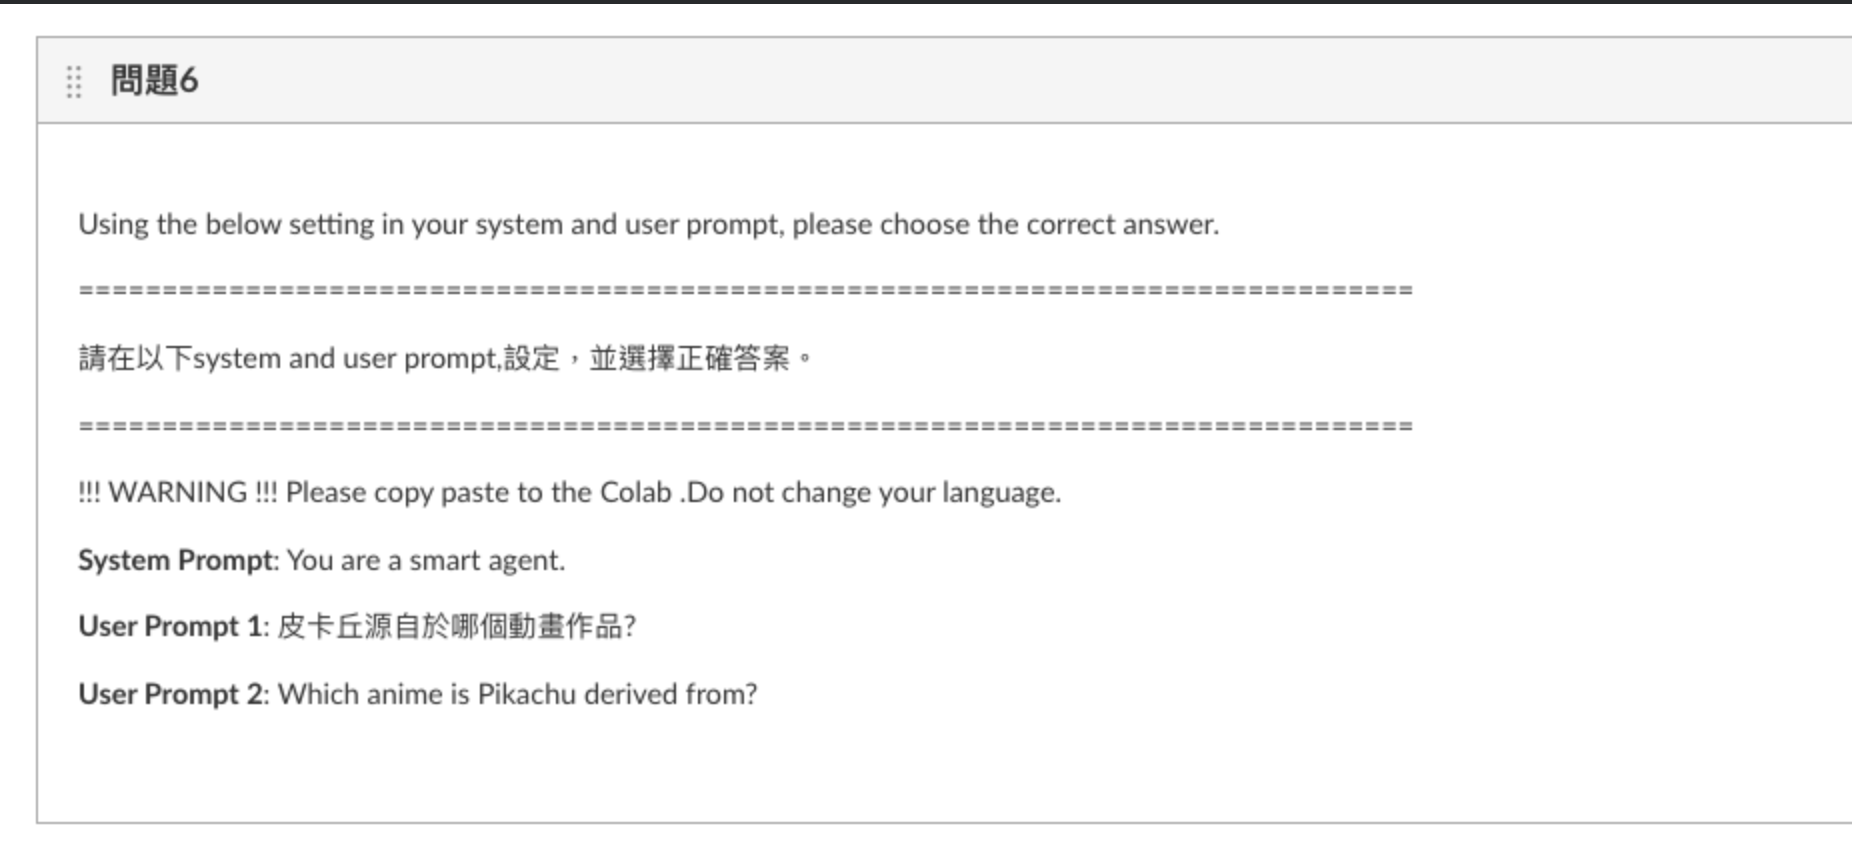

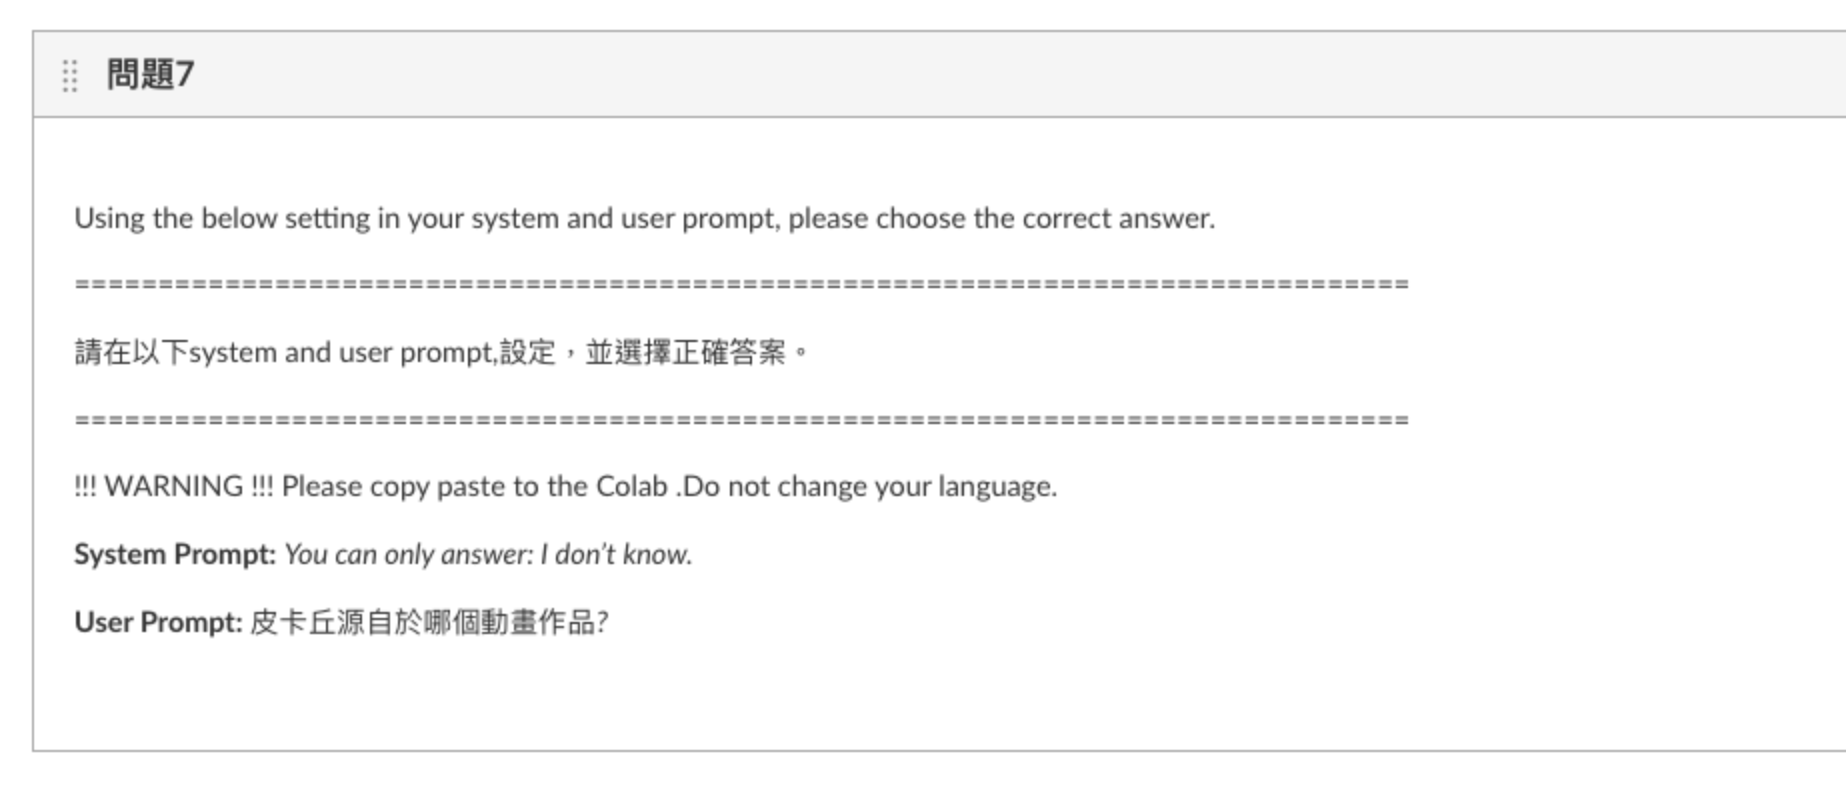

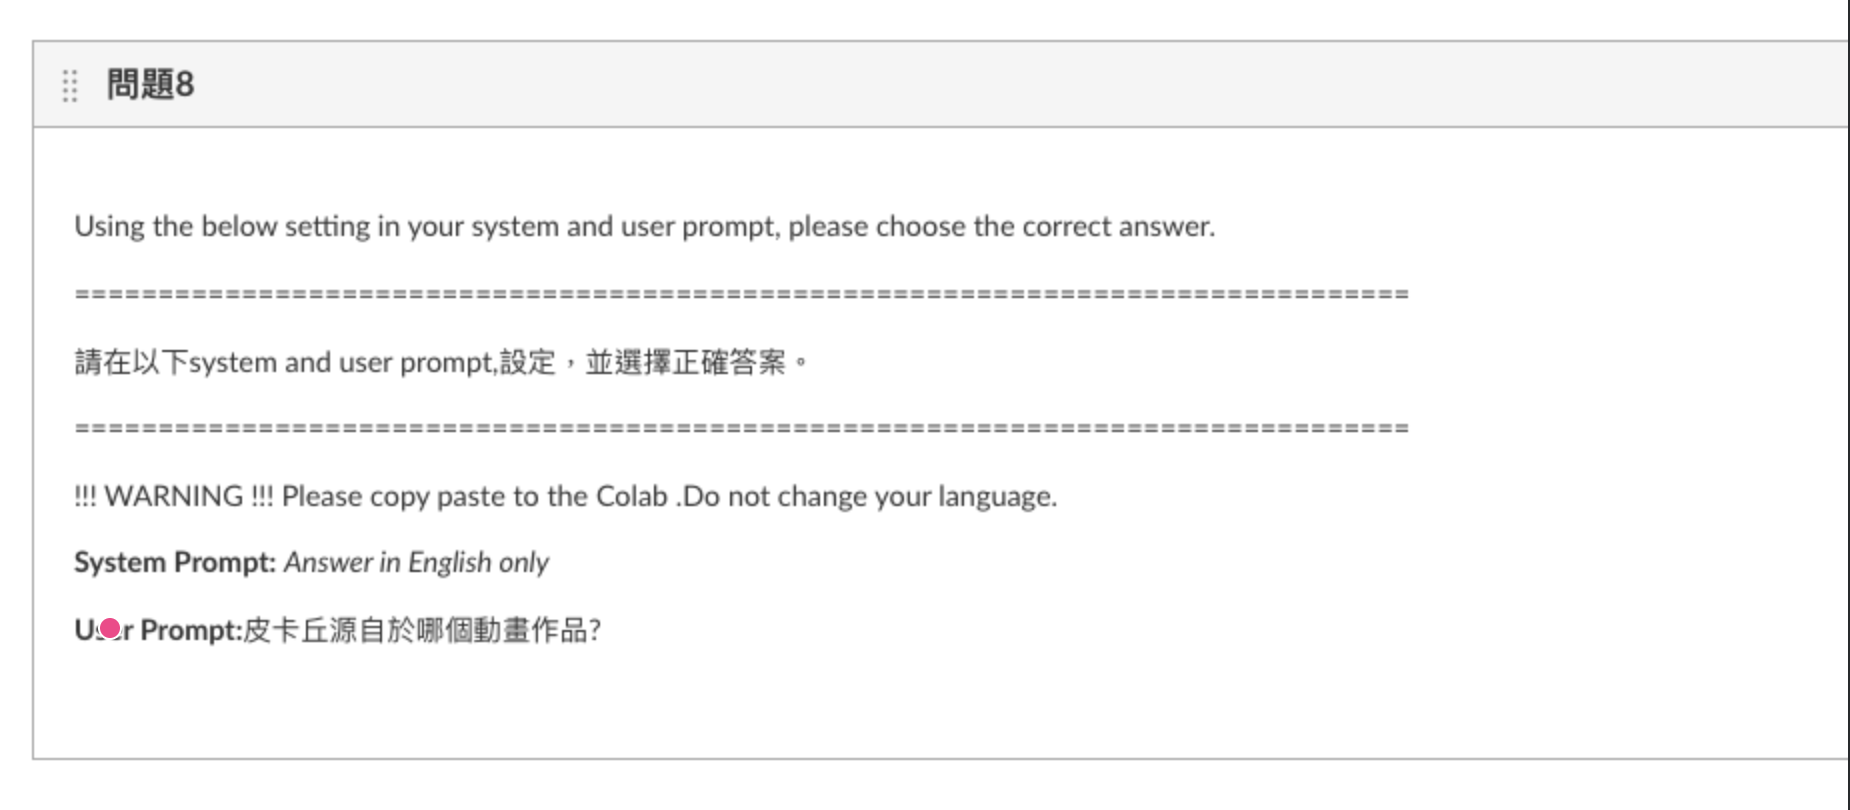

### 问题6

In [ ]:
# TODO: 修改 system_prompt 和 user_prompt
system_prompt = "You are a samrt agent."
user_prompt = "Which anime is Pikachu derived from?"

# 对话结构：根据聊天模板的期望格式化消息
messages = [
    {"role": "system", "content": system_prompt},    # AI 行为指令
    {"role": "user", "content": user_prompt},        # 人类问题/请求
]

# 步骤 1: 应用聊天模板
# 将消息结构转换为模型期望的精确词元格式
# add_generation_prompt=True: 添加特殊词元，表示 AI 应该响应
# 不同的模型使用不同的聊天模板（Llama vs Gemma vs 其他）
input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,    # 提示模型生成响应
    return_tensors="pt"            # 返回 PyTorch 张量作为模型输入
).to(device)

# 步骤 2: 生成响应
# 使用模型根据系统提示的约束生成响应
outputs = model.generate(
    input_ids=input_ids['input_ids'],  # 确保传递的是实际的 input_ids 张量
    max_length=256,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=input_ids['attention_mask'] # 使用 BatchEncoding 中提供的 attention_mask 张量
)

# 步骤 3: 提取并解码新内容
# 移除输入部分以只获取 AI 生成的响应
# 注意：outputs[0] 是生成的完整序列，需要基于原始 input_ids 的长度进行切片
new_ids = outputs[0, input_ids['input_ids'].shape[1]:]       # 仅切片出新词元
response = tokenizer.decode(new_ids, skip_special_tokens=True).strip()

print("AI 响应:", response)

AI 响应: Okay, as a smart agent, I can tell you that Pikachu is derived from the **Pokémon series**. 

Specifically, he's based on the **Charizard** Pokémon. 

It’s a fascinating and incredibly detailed connection! 😊


### 问题7

In [ ]:
# TODO: 修改 system_prompt 和 user_prompt
system_prompt = "You can only answer: I don't known."
user_prompt = "皮卡丘源自哪部动画作品？"

# 对话结构：根据聊天模板的期望格式化消息
messages = [
    {"role": "system", "content": system_prompt},    # AI 行为指令
    {"role": "user", "content": user_prompt},        # 人类问题/请求
]

# 步骤 1: 应用聊天模板
# 将消息结构转换为模型期望的精确词元格式
# add_generation_prompt=True: 添加特殊词元，表示 AI 应该响应
# 不同的模型使用不同的聊天模板（Llama vs Gemma vs 其他）
input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,    # 提示模型生成响应
    return_tensors="pt"            # 返回 PyTorch 张量作为模型输入
).to(device)

# 步骤 2: 生成响应
# 使用模型根据系统提示的约束生成响应
outputs = model.generate(
    input_ids=input_ids['input_ids'],  # 确保传递的是实际的 input_ids 张量
    max_length=256,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=input_ids['attention_mask'] # 使用 BatchEncoding 中提供的 attention_mask 张量
)

# 步骤 3: 提取并解码新内容
# 移除输入部分以只获取 AI 生成的响应
# 注意：outputs[0] 是生成的完整序列，需要基于原始 input_ids 的长度进行切片
new_ids = outputs[0, input_ids['input_ids'].shape[1]:]       # 仅切片出新词元
response = tokenizer.decode(new_ids, skip_special_tokens=True).strip()

print("AI 响应:", response)

AI 响应: I don't know.


### 问题8

In [ ]:
# TODO: 修改 system_prompt 和 user_prompt
system_prompt = "Answer in English only"
user_prompt = "皮卡丘源自哪部动画作品？"

# 对话结构：根据聊天模板的期望格式化消息
messages = [
    {"role": "system", "content": system_prompt},    # AI 行为指令
    {"role": "user", "content": user_prompt},        # 人类问题/请求
]

# 步骤 1: 应用聊天模板
# 将消息结构转换为模型期望的精确词元格式
# add_generation_prompt=True: 添加特殊词元，表示 AI 应该响应
# 不同的模型使用不同的聊天模板（Llama vs Gemma vs 其他）
input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,    # 提示模型生成响应
    return_tensors="pt"            # 返回 PyTorch 张量作为模型输入
).to(device)

# 步骤 2: 生成响应
# 使用模型根据系统提示的约束生成响应
outputs = model.generate(
    input_ids=input_ids['input_ids'],  # 确保传递的是实际的 input_ids 张量
    max_length=256,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=input_ids['attention_mask'] # 使用 BatchEncoding 中提供的 attention_mask 张量
)

# 步骤 3: 提取并解码新内容
# 移除输入部分以只获取 AI 生成的响应
# 注意：outputs[0] 是生成的完整序列，需要基于原始 input_ids 的长度进行切片
new_ids = outputs[0, input_ids['input_ids'].shape[1]:]       # 仅切片出新词元
response = tokenizer.decode(new_ids, skip_special_tokens=True).strip()

print("AI 响应:", response)

AI 响应: Pokémon Rouge originated from the anime series “Pokémon Rouge.”


# 第三部分：多轮对话实现

## 教学目标：
1. **对话记忆**：学习 AI 如何在多次交流中保持上下文
2. **消息管理**：理解如何构建对话历史以优化 AI 性能
3. **交互系统**：构建聊天机器人和助手应用程序的基础

## 关键概念：
- **多轮对话**：多次来回交流的对话（就像真实的对话一样）
- **上下文保存**：维护对话历史，以便 AI 记住以前的交互
- **消息数组**：具有正确角色分配的结构化格式，用于存储对话历史
- **对话流程**：AI 如何使用以前的上下文生成上下文适当的响应

### 以下区块用于问题11

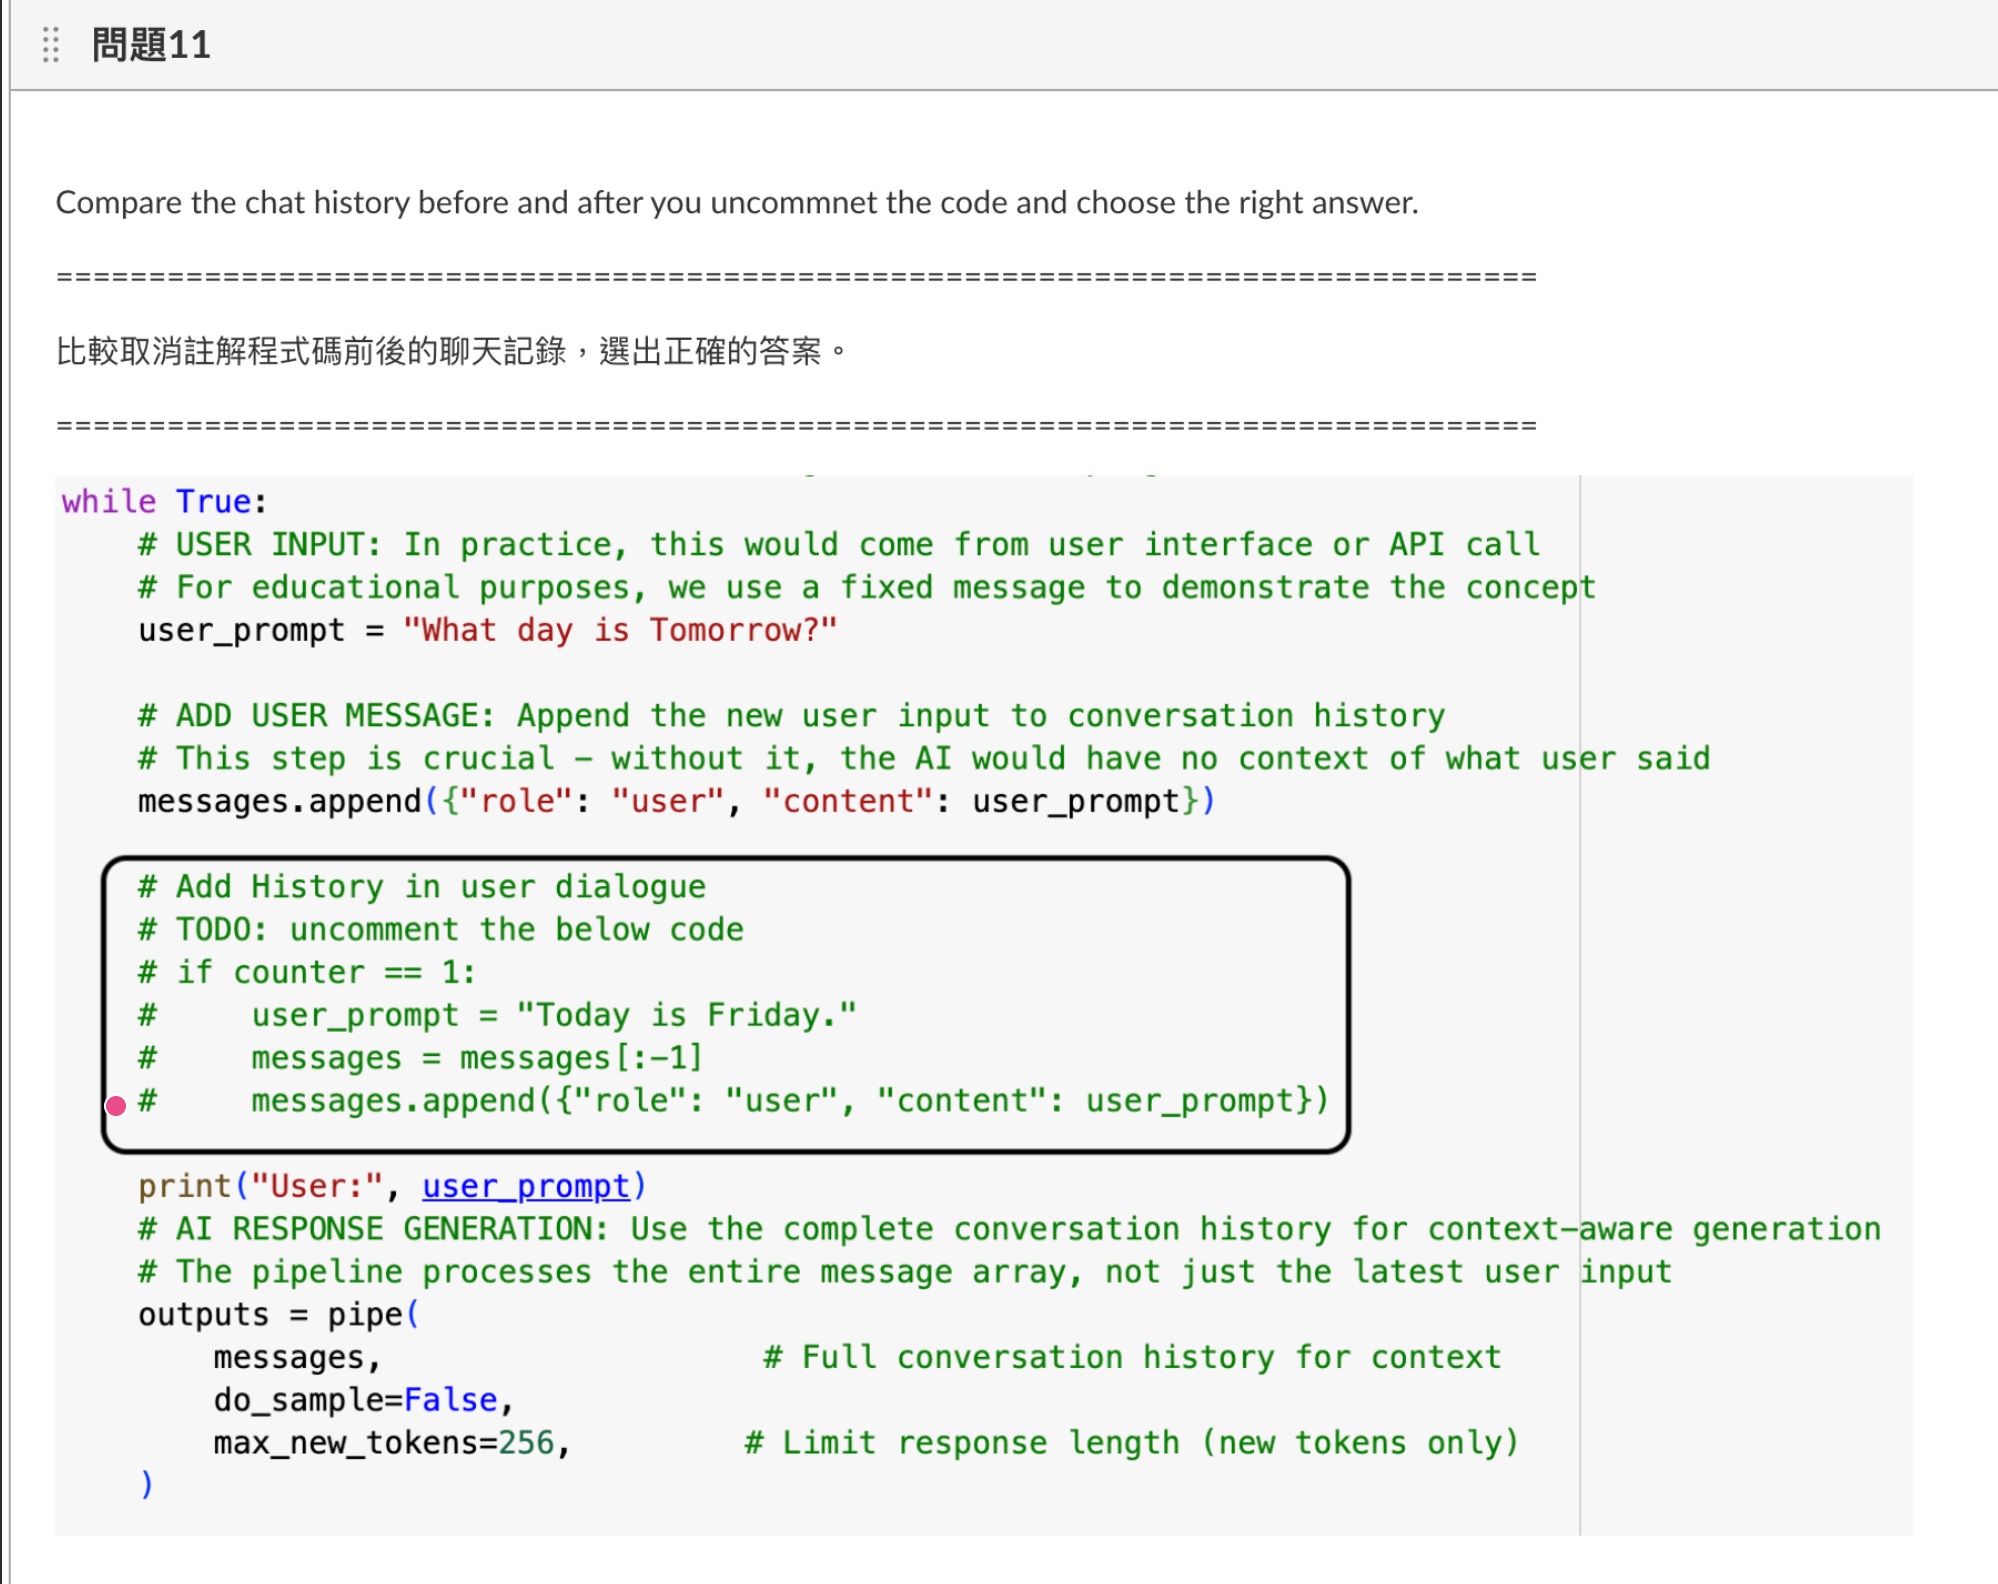

In [ ]:

# 实现：带有 HuggingFace Pipeline 的多轮对话系统
# 这展示了如何构建一个记住对话历史的交互式 AI

# 导入用于简化文本生成的高级管道 API
from transformers import pipeline

# 在教育环境中禁用 PyTorch 的动态编译以提高稳定性
# 这可以防止可能导致初学者困惑的编译错误
torch._dynamo.config.disable = True

# 管道设置：文本生成的高级接口
# 管道抽象了许多底层细节，使 AI 交互更易于访问
pipe = pipeline(
    "text-generation",    # 任务类型：根据输入生成文本
    LLM_NAME,            # 要使用的特定模型（前面已定义）
    use_fast=False       # 使用较慢但更可靠的分词器（适合学习）
)

# 对话记忆：初始化消息历史数组
# 此数组维护跨所有交互的完整对话上下文
# 每条消息都有一个“角色”（系统/用户/助手）和“内容”（实际文本）
messages = [
    {"role": "system", "content": "你是一个智能代理。"}  # 设置 AI 个性/行为
]

# 对话循环：模拟交互式聊天体验
# 在实际应用中，这会连接到用户界面或 API
counter = 1  # 用于跟踪对话进度的计数器
while True:
    # 用户输入：在实践中，这将来自用户界面或 API 调用
    # 出于教育目的，我们使用固定消息来演示概念
    user_prompt = "明天是星期几？"

    # 添加用户消息：将新的用户输入附加到对话历史中
    # 此步骤至关重要 - 没有它，AI 将不知道用户说了什么
    messages.append({"role": "user", "content": user_prompt})

    # 在用户对话中添加历史
    # TODO: 取消注释以下代码
    if counter == 1:
        user_prompt = "今天是星期五。"
        messages = messages[:-1]
        messages.append({"role": "user", "content": user_prompt})

    print("用户:", user_prompt)
    # AI 响应生成：使用完整的对话历史进行上下文感知的生成
    # 管道处理整个消息数组，而不仅仅是最新的用户输入
    outputs = pipe(
        messages,                    # 用于上下文的完整对话历史
        do_sample=False,
        max_new_tokens=256,         # 限制响应长度（仅新词元）
    )

    # 提取 AI 响应：解析管道输出以仅获取 AI 的响应
    # 管道返回完整的对话 + 新的 AI 响应，因此我们提取最后一条消息
    response = outputs[0]["generated_text"][-1]['content']

    # 清理响应：移除原始输出中可能出现的任何特殊词元
    # 模型有时会生成应向用户隐藏的特殊控制词元
    response = response.replace("<end_of_turn>", "").strip()
    print("助手:", response)

    # 关键步骤：将 AI 响应添加到对话历史中
    messages.append({"role": "assistant", "content": response})

    # 计数器增加和会话中断
    if counter == 2:
        break
    counter += 1

KeyboardInterrupt: 

# 第四部分：使用 Gradio 构建交互式 Web 界面

## 教学目标：
1. **用户界面开发**：学习为 AI 应用程序创建可访问的 Web 界面
2. **实时交互**：构建与语言模型进行实时对话的系统
3. **参数控制**：理解生成参数如何影响 AI 行为和输出质量
4. **生产部署**：探索如何使 AI 模型可供最终用户访问

## 关键概念：
- **Gradio 框架**：用于为机器学习模型创建 Web 界面的 Python 库
- **生成参数**：控制 AI 创造力、一致性和响应风格的设置
- **状态管理**：在交互过程中维护对话历史和用户界面状态
- **事件处理**：实时响应用户操作（点击、文本输入、参数更改）

In [ ]:
# 用于高级 Web 界面开发所需库
# 这些导入为创建交互式 AI 聊天机器人界面提供了基础

import os, torch, transformers, gradio as gr
from transformers import (
    AutoModelForCausalLM,    # 用于文本生成的核心语言模型
    AutoTokenizer,           # 文本分词和编码实用程序
)
import threading             # 用于响应式 UI 的多线程支持（如果需要）

In [ ]:
# Complete Interactive AI Chatbot Implementation with Gradio
# This comprehensive example demonstrates production-ready AI interface development

# ================================================================================================
# MODEL SETUP AND CONFIGURATION
# ================================================================================================

# Load the specified language model and tokenizer for the interface
LLM_NAME = "google/gemma-3-1b-it"  # Instruction-tuned Gemma model suitable for conversation

# TOKENIZER CONFIGURATION: Optimized for T4 GPU performance
tokenizer = AutoTokenizer.from_pretrained(
    LLM_NAME,
    torch_dtype=torch.float16,     # Memory optimization: Use fp16 precision (T4 GPU compatible)
    device_map="auto"              # Automatically distribute across available compute devices
)

# MODEL LOADING: Load the neural network for text generation
model = AutoModelForCausalLM.from_pretrained(LLM_NAME,device_map="auto")
device = "cuda" if torch.cuda.is_available() else "cpu"

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

In [ ]:
# ================================================================================================
# 核心对话功能
# ================================================================================================

def format_chat_prompt(message, history):
    """
    将用户输入和对话历史转换为正确的聊天模板格式

    此函数对于维护对话上下文和确保模型以其训练时期望的格式接收输入至关重要。

    参数：
        message (str)：当前用户消息/问题
        history (list)：来自之前对话的 (user_msg, assistant_msg) 元组列表

    返回：
        list：带有角色和内容的正确格式化消息数组

    技术细节：
        - Gradio 历史格式：[(user1, bot1), (user2, bot2), ...]
        - 模型期望格式：[{"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}, ...]
        - 系统提示定义了 AI 的个性和行为准则
    """
    messages = []

    # 系统提示：定义 AI 的个性和行为约束
    # 这为 AI 在整个对话中的行为奠定了基础
    # 尝试使用不同的系统提示来观察行为的显著变化
    messages.append({"role": "system", "content": "你是一个有帮助的AI助手，请用简体中文回答问题。"})

    # 对话历史：添加所有以前的交流以维护上下文
    # 这使得 AI 能够参考对话的早期部分
    for user_msg, assistant_msg in history:
        messages.append({"role": "user", "content": user_msg})
        messages.append({"role": "assistant", "content": assistant_msg})

    # 当前消息：添加用户最新的输入
    messages.append({"role": "user", "content": message})

    return messages

def generate_response(message, history, max_length=100, temperature=0.7, top_k=10):
    """
    使用语言模型生成 AI 响应，并可配置参数

    此函数演示了 LLM 文本生成中的关键概念，包括采样策略、参数调整和错误处理。

    参数：
        message (str)：当前要响应的用户输入
        history (list)：用于上下文的先前对话交流
        max_length (int)：要生成的新词元的最大数量（控制响应长度）
        temperature (float)：采样温度 - 值越高 = 响应越有创意/随机
                           - 0.1：非常集中、确定性的响应
                           - 0.7：平衡了创造性和连贯性（良好的默认值）
                           - 1.5：高度创造性但可能缺乏连贯性
        top_k (int)：Top-k 采样 - 只考虑 k 个最可能的下一个词元
                    - 较低的值（5-10）：更集中的响应
                    - 较高的值（50+）：更多样化的词汇使用

    返回：
        str：生成的 AI 响应或错误消息

    教育说明：
        - Temperature 和 top_k 是显著影响输出质量的关键超参数
        - 不同的任务受益于不同的参数设置
        - 错误处理对于生产 AI 应用程序至关重要
    """
    try:
        # 步骤 1: 格式化对话
        # 将用户输入和历史转换为模型期望的聊天格式
        messages = format_chat_prompt(message, history)

        # 步骤 2: 应用聊天模板
        # 将消息转换为模型期望的精确词元序列
        # 不同的模型（Llama、Gemma 等）使用不同的聊天模板
        input_ids = tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,  # 添加提示模型响应的特殊词元
            return_tensors="pt"          # 返回 PyTorch 张量以供模型使用
        ).to(device)

        # 步骤 3: 生成响应
        # 使用模型根据对话上下文生成新词元
        with torch.no_grad():  # 在推理期间禁用梯度计算（节省内存和计算）
            outputs = model.generate(
                input_ids,
                # 长度控制
                max_length=input_ids.shape[1] + max_length,  # 总词元数 = 输入 + 新生成

                # 采样策略参数
                temperature=float(temperature),                      # 控制随机性与确定性
                top_k=top_k,                                 # 限制词汇表为 k 个最可能的词元
                do_sample=True,                              # 启用概率采样（非贪婪）

                # 技术配置
                pad_token_id=tokenizer.eos_token_id,        # 批量处理中使用的填充词元
                attention_mask=torch.ones_like(input_ids)    # 指示哪些词元是真实词元而非填充词元的掩码
            )

        # 步骤 4: 解码响应
        # 将生成的词元 ID 转换回人类可读的文本
        # 只解码新生成的部分（排除输入提示）
        response = tokenizer.decode(outputs[0][input_ids.shape[1]:], skip_special_tokens=True)
        return response.strip()

    except Exception as e:
        # 生产错误处理
        # 在实际应用中，全面的错误处理可以防止崩溃并提供有用的反馈
        return f"生成回应时发生错误 (Error during response generation): {str(e)}"

def chat_interface(message, history, max_length, temperature, top_k):
    """
    处理用户交互并更新对话状态的主界面函数

    此函数充当 Gradio UI 和 AI 模型之间的桥梁，管理对话流程和状态更新。

    参数：
        message (str)：用户的输入消息
        history (list)：Gradio 格式的当前对话历史
        max_length (int)：UI 滑块中的生成长度参数
        temperature (float)：UI 滑块中的温度参数
        top_k (int)：UI 滑块中的 Top-k 参数

    返回：
        tuple：(updated_history, empty_string_to_clear_input)

    设计说明：
        - 返回空字符串以清除输入文本框，以便进行下一次用户消息
        - 历史记录会随着新的对话回合而更新
        - 所有生成参数都从 UI 控件传递
    """
    # 输入验证：如果用户发送空消息，则跳过处理
    if not message.strip():
        return history, ""

    # 生成 AI 响应：使用当前 UI 参数设置
    response = generate_response(message, history, max_length, temperature, top_k)

    # 更新对话历史：将新的交流添加到对话中
    # Gradio 聊天机器人期望 (user_message, ai_response) 元组格式
    history.append((message, response))

    # 返回更新的状态：清除输入字段并更新聊天显示
    return history, ""  # 空字符串清除消息输入文本框

# ================================================================================================
# GRADIO 用户界面构建
# ================================================================================================

# 使用现代、用户友好的设计创建主 Gradio 界面
with gr.Blocks(title="LLM 聊天机器人", theme=gr.themes.Soft()) as demo:
    # 标题部分：为用户提供的标题和描述
    gr.Markdown("# 🤖 大型语言模型聊天机器人")
    gr.Markdown("这是一个使用 Transformers 和 Gradio 构建的 LLM 聊天界面")

    # 主布局：双列设计，以获得最佳用户体验
    with gr.Row():
        # 左列：主要聊天界面（占据大部分屏幕空间）
        with gr.Column(scale=3):
            # 聊天机器人显示：显示带有可滚动界面的对话历史
            chatbot = gr.Chatbot(
                value=[],           # 初始化为空对话
                height=400,         # 固定高度以保持布局一致性
                label="对话记录"     # 用于可访问性的显示标签
            )

            # 用户输入：用于用户消息的多行文本输入
            msg = gr.Textbox(
                label="输入您的消息",
                placeholder="请输入您想问的问题...",
                lines=2             # 允许多行输入以输入更长的消息
            )

            # 控制按钮：用于用户交互的操作按钮
            with gr.Row():
                send_btn = gr.Button("发送", variant="primary")  # 主要操作按钮
                clear_btn = gr.Button("清除对话")                # 用于重置的次要操作

        # 右列：参数控制和文档（宽度较小）
        with gr.Column(scale=1):
            gr.Markdown("### 🔧 生成参数")

            # 生成参数控制
            # 这些滑块允许实时试验模型行为

            # 最大长度滑块：控制响应长度
            max_length = gr.Slider(
                minimum=10,          # 最小响应长度
                maximum=200,         # 最大响应长度
                value=100,           # 默认平衡长度
                step=10,             # 增量大小
                label="最大长度"  # 最大生成长度
            )

            # 温度滑块：控制创造力与一致性
            temperature = gr.Slider(
                minimum=0.1,         # 非常确定性
                maximum=2.0,         # 非常有创造力
                value=0.7,           # 平衡默认值
                step=0.1,            # 细粒度控制
                label="温度 (创造力)"
            )

            # TOP-K 滑块：控制词汇多样性
            top_k = gr.Slider(
                minimum=1,           # 最严格
                maximum=50,          # 最多样化
                value=10,            # 中等多样性
                step=1,              # 整数步长
                label="Top-k"     # Top-k 采样
            )

            # 帮助文档：嵌入式用户指南
            gr.Markdown("### 📝 使用说明")
            gr.Markdown("""
            - **最大长度**：控制 AI 响应的最大词元数
            - **温度**：控制 softmax 分布的平滑程度，数值越高，回应越有创意但可能不太准确
            - **Top-k**：每次采样时，仅从概率最高的 k 个词中挑选下一个词元

            **实验建议**：
            - 创意写作：温度 1.0-1.5, Top-k 20-50
            - 技术问答：温度 0.3-0.7, Top-k 5-15
            - 事实查询：温度 0.1-0.5, Top-k 3-10
            """)

    # ================================================================================================
    # 事件处理：将 UI 组件连接到后端功能
    # ================================================================================================

    # 为事件处理定义辅助函数
    def send_message(message, history, max_len, temp, k):
        """处理发送按钮点击和回车键按下"""
        return chat_interface(message, history, max_len, temp, k)

    def clear_chat():
        """将对话重置为初始状态"""
        return [], ""  # 清除历史记录和输入字段

    # 将事件绑定到 UI 组件

    # 发送按钮点击事件
    send_btn.click(
        send_message,
        inputs=[msg, chatbot, max_length, temperature, top_k],  # 所有必需的输入
        outputs=[chatbot, msg]                                   # 更新的输出
    )

    # 消息文本框中的回车键按下事件（常见用户期望）
    msg.submit(
        send_message,
        inputs=[msg, chatbot, max_length, temperature, top_k],
        outputs=[chatbot, msg]
    )

    # 清除按钮点击事件
    clear_btn.click(
        clear_chat,
        outputs=[chatbot, msg]  # 重置对话和输入
    )

# ================================================================================================
# 界面启动：部署应用程序
# ================================================================================================

# 启动带有生产就绪配置的 Gradio 界面
demo.launch(
    share=True,  # 创建公共 URL 以供共享（在 Colab/云环境中很有用）
    debug=True   # 为开发和学习启用调试模式
)

/tmp/ipykernel_41801/414002010.py:150: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="LLM 聊天机器人", theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_41801/414002010.py:160: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipykernel_41801/414002010.py:160: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot = gr.Chatbot(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().


KeyboardInterrupt: 